In [35]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from glance.overlapper import overlap_pixel_healpy, make_map_healpy, hpd_threshold_healpy

In [36]:
ra_1_mean = 1
dec_1_mean = 0.2
ra_1_sigma = 0.2
dec_1_sigma = 0.3

ra_2_mean = 1.5
dec_2_mean = 0.25
ra_2_sigma = 0.1
dec_2_sigma = 0.3

N = 1e4

ra_1 = np.random.normal(ra_1_mean, ra_1_sigma, size=int(N))
dec_1 = np.random.normal(dec_1_mean, dec_1_sigma, size=int(N))
ra_2 = np.random.normal(ra_2_mean, ra_2_sigma, size=int(N))
dec_2 = np.random.normal(dec_2_mean, dec_2_sigma, size=int(N))

In [37]:
nside = 128
smooth_sigma_deg = 0.
threshold = 0.9

ra_overlap, dec_overlap, m1, m2 = overlap_pixel_healpy(ra_1, dec_1, ra_2, dec_2, 
                  nside, smooth_sigma_deg, threshold, return_maps=True)


Overlap exists


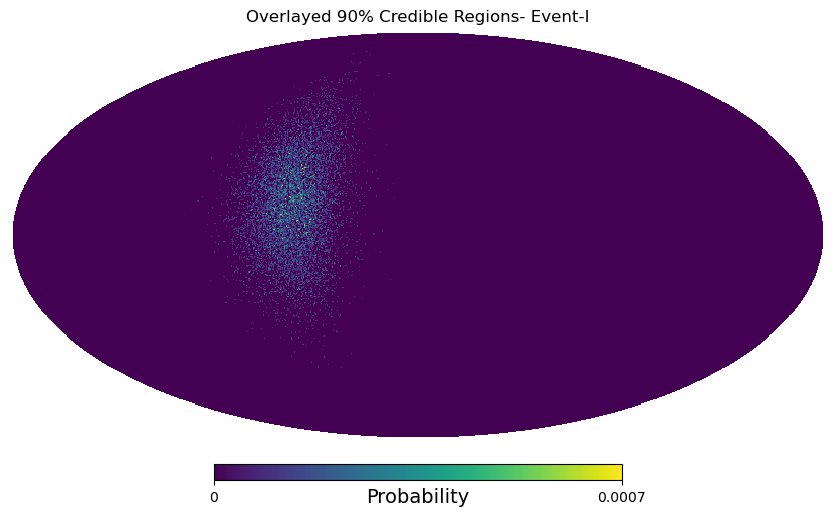

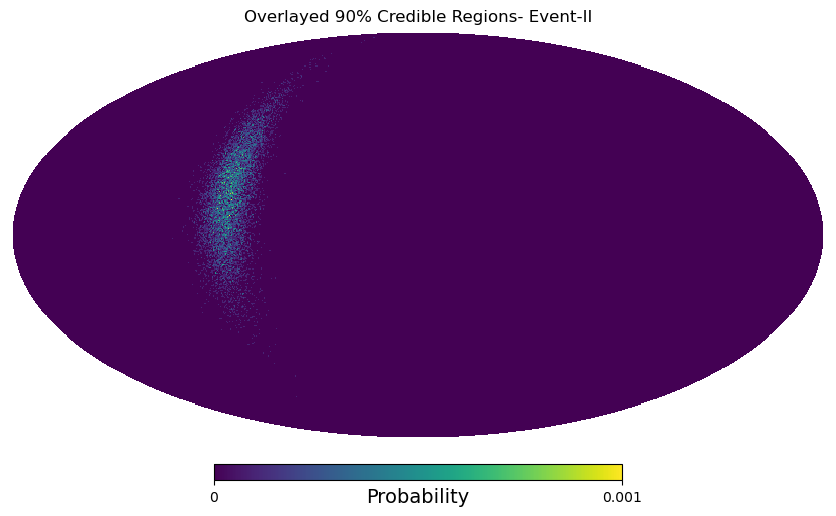

In [38]:
hp.mollview(m1, title=f"Overlayed {int(threshold*100)}% Credible Regions- Event-I", unit="Probability")
hp.mollview(m2, title=f"Overlayed {int(threshold*100)}% Credible Regions- Event-II", unit="Probability")

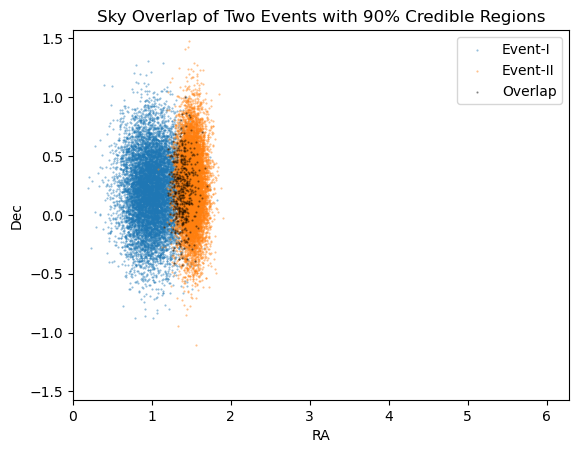

In [39]:
plt.scatter(ra_1, dec_1, label="Event-I", s=0.25, alpha=0.5)
plt.scatter(ra_2, dec_2, label="Event-II", s=0.25, alpha=0.5)
plt.scatter(ra_overlap, dec_overlap, label="Overlap", s=0.25, alpha=0.5, color='k', marker='x')
plt.xlabel("RA")
plt.ylabel("Dec")
plt.legend()
plt.title(f"Sky Overlap of Two Events with {int(threshold*100)}% Credible Regions")
plt.xlim(0, 2*np.pi)
plt.ylim(-np.pi/2, np.pi/2)
plt.show() 

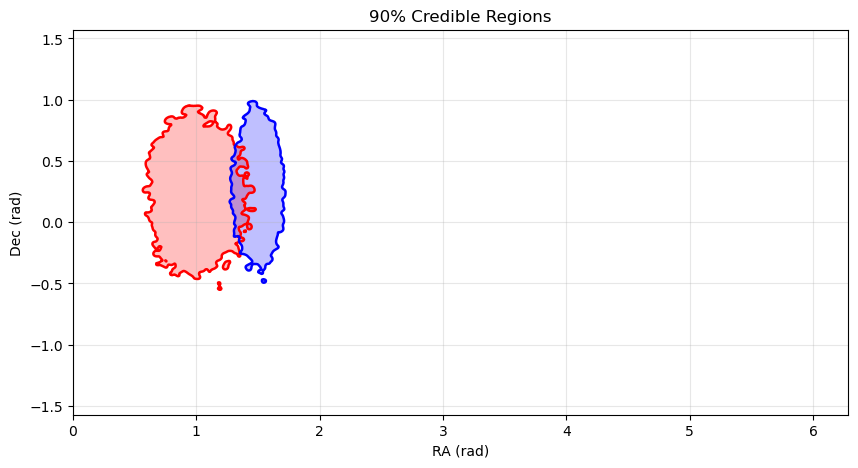

In [46]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import matplotlib.tri as tri

nside = 128
npix = hp.nside2npix(nside)


m1 = make_map_healpy(ra_1, dec_1, nside, smooth_sigma_deg=0.9)
m2 = make_map_healpy(ra_2, dec_2, nside, smooth_sigma_deg=0.9)

thr1 = hpd_threshold_healpy(m1, 0.9)
thr2 = hpd_threshold_healpy(m2, 0.9)

theta_pix, phi_pix = hp.pix2ang(nside, np.arange(npix))

X = phi_pix 
Y = np.pi/2 - theta_pix
X = np.where(X > np.pi, X - 2*np.pi, X)

triang = tri.Triangulation(X, Y)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)

ax.set_xlim(0, 2*np.pi)
ax.set_ylim(-np.pi/2, np.pi/2)

ax.set_xlabel("RA (rad)")
ax.set_ylabel("Dec (rad)")
ax.set_title("90% Credible Regions")

ax.grid(True, alpha=0.3)

c1 = ax.tricontour(triang, m1,
                   levels=[thr1],
                   colors='red', linewidths=1.8)

c2 = ax.tricontour(triang, m2,
                   levels=[thr2],
                   colors='blue', linewidths=1.8)

ax.tricontourf(triang, m1,
               levels=[thr1, m1.max()],
               colors='red', alpha=0.25)

ax.tricontourf(triang, m2,
               levels=[thr2, m2.max()],
               colors='blue', alpha=0.25)
plt.show()